[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MaxMitre/Mate_MercadosFinancieros/blob/main/Semana14_VolatilidadImplicita.ipynb)

# Volatilidad implicita

In [ ]:
import os

import time
import numpy as np
import scipy as sci
import scipy.io as sio
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler


import tensorflow as tf
from tensorflow.keras.layers import Dense
from tensorflow import keras


from numpy.random import seed
seed(100)


import matplotlib.pyplot as plt
from IPython.display import clear_output


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
raw = pd.read_csv(os.path.join('/content/drive/MyDrive/Cruso-ApsFinancieras/volatilitySurface/Implied_Volatility_Data_vFinal.csv'))
# check the raw data
print("Size of the dataset (row, col): ", raw.shape)
raw.head(n=5)

Size of the dataset (row, col):  (125700, 5)


,Date,SPX Return,Time to Maturity in Year,Delta,Implied Volatility Change
0,20140630,0.006678,0.184,0.745927,0.008462
1,20140630,0.006678,2.252,0.286911,0.002024
2,20140630,0.006678,0.124,0.902941,0.019707
3,20140630,0.006678,2.144,0.910926,0.006424
4,20140630,0.006678,1.412,0.885760,0.005673


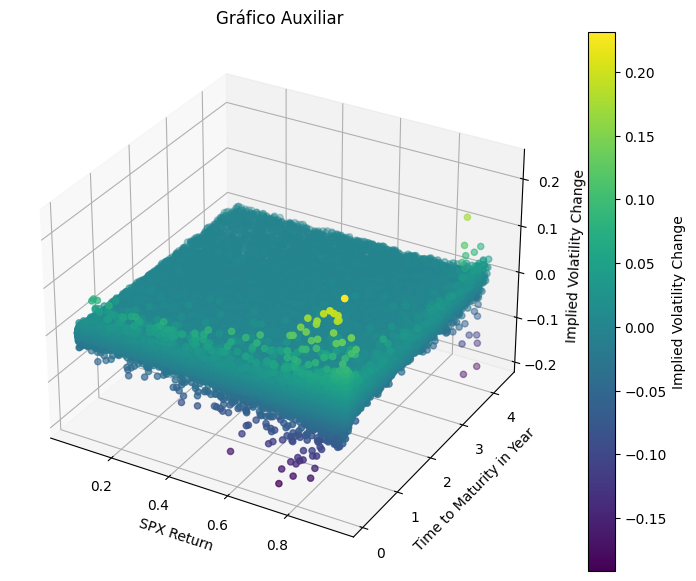

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

# Extract necessary columns from the dataframe
x = raw['Delta']
y = raw['Time to Maturity in Year']
z = raw['Implied Volatility Change']

# Create the 3D plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of the data points
sc = ax.scatter(x, y, z, c=z, cmap='viridis')

# Add labels
ax.set_xlabel('SPX Return')
ax.set_ylabel('Time to Maturity in Year')
ax.set_zlabel('Implied Volatility Change')
ax.set_title('Gráfico Auxiliar')

# Color bar for reference
fig.colorbar(sc, ax=ax, label='Implied Volatility Change')

plt.show()


In [ ]:
import plotly.graph_objects as go

# Extract necessary columns
x = raw['SPX Return']
y = raw['Time to Maturity in Year']
z = raw['Implied Volatility Change']

# Create 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=x, y=y, z=z,
    mode='markers',
    marker=dict(
        size=5,
        color=z,           # set color to the z-axis variable
        colorscale='Viridis',
        colorbar=dict(title='Implied Volatility Change'),
        opacity=0.8
    )
)])

# Update layout
fig.update_layout(
    scene=dict(
        xaxis_title='SPX Return',
        yaxis_title='Time to Maturity in Year',
        zaxis_title='Implied Volatility Change'
    ),
    title='Gráfico Auxiliar Interactivo',
    width=800,
    height=600
)

# Show plot
fig.show()


## Construct the 3 variables for Regression Approach

In [ ]:
# construct the 3 variables for regression
raw['x1'] = raw['SPX Return'] / np.sqrt(raw['Time to Maturity in Year'])
raw['x2'] = raw['SPX Return'] / np.sqrt(raw['Time to Maturity in Year']) * raw['Delta']
raw['x3'] = raw['x2'] * raw['Delta']

# Put the X and Y variable in data frame for regression
y = raw['Implied Volatility Change']
X = raw[['x1', 'x2', 'x3','SPX Return','Time to Maturity in Year','Delta']]

In [ ]:
X.head()

,x1,x2,x3,SPX Return,Time to Maturity in Year,Delta
0,0.015568,0.011612,0.008662,0.006678,0.184,0.745927
1,0.004450,0.001277,0.000366,0.006678,2.252,0.286911
2,0.018964,0.017123,0.015461,0.006678,0.124,0.902941
3,0.004561,0.004154,0.003784,0.006678,2.144,0.910926
4,0.005620,0.004978,0.004409,0.006678,1.412,0.885760


In [ ]:
# Divide data into training set and test set(note that random seed is set)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=100)

# Divide training set into training and validation set
X_train,X_val,y_train,y_val=train_test_split(X_train,y_train,test_size=0.25,random_state=100)

## Feature Scaling

In [ ]:
# Scale features based on Z-Score
scaler = StandardScaler()
scaler.fit(X_train)


X_scaled_train = scaler.transform(X_train)
X_scaled_vals = scaler.transform(X_val)
X_scaled_test = scaler.transform(X_test)
y_train = np.asarray(y_train)
y_val = np.asarray(y_val)
y_test = np.asarray(y_test)

## Run Regression

In [ ]:
# Run the regression on the training data
lr = LinearRegression(fit_intercept=False)
lr.fit(X_scaled_train[:,:3], y_train)

# Get the prediction
y_pred = lr.predict(X_scaled_test[:,:3])

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)

print('Test loss (MSE):', mse)

Test loss (MSE): 7.423167462421238e-05


## ML Approach

In [ ]:
# Create ML Model
# Sequential function allows you to define your Neural Network in sequential order
# Within Sequential, use Dense function to define number of nodes, activation function and other related parameters
# For more information regrading to activation functoin, please refer to https://keras.io/activations/
model = keras.models.Sequential([Dense(20,activation = "sigmoid",input_shape = (3,)),
                                 Dense(20,activation = "sigmoid"),
                                 Dense(20,activation = "sigmoid"),
                                Dense(1)])

# Model summary function shows what you created in the model
model.summary()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 20)                  │              80 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 20)                  │             420 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 20)                  │             420 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              21 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 941 (3.68 KB)

 Trainable params: 941 (3.68 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Complie function allows you to choose your measure of loss and optimzer
# For other optimizer, please refer to https://keras.io/optimizers/
model.compile(loss = "mse",optimizer = "Adam")

In [ ]:
# Checkpoint function is used here to periodically save a copy of the model.
# Currently it is set to save the best performing model
checkpoint_cb = keras.callbacks.ModelCheckpoint("implied_vol_model_vFinal.keras",save_best_only = True)

# Early stopping allows you to stop your training early if no improvment is shown after cerain period
# Currently it is set at if no improvement occured in 1000 epochs, at the stop the model will also revert back to the best weight
early_stopping_cb = keras.callbacks.EarlyStopping(patience = 1000,restore_best_weights = True)

# Remark: checkpoint could be redundant here as early stopping function can also help restoring to the best weight
# We put both here just to illustrate different ways to keep the best model


In [ ]:
# train your model
# The fit function allows you to train a NN model. Here we have training data, number of epochs,batch size, validation data,
# and callbacks as input
# Callback is an optional parameters that allow you to enable tricks for training such as early stopping and checkpoint

# Remarks: Altough we put 50000 epochs here, the model will stop its training once our early stopping criterion is triggered

history=model.fit(X_scaled_train[:,3:6],y_train,epochs=1000, batch_size = 128, verbose = 1, validation_data=(X_scaled_vals[:,3:6],y_val),
                 callbacks=[checkpoint_cb, early_stopping_cb])






In [ ]:
# Load the best model you saved and calcuate MSE for testing set

model = keras.models.load_model("/content/drive/MyDrive/Cruso-ApsFinancieras/volatilitySurface/implied_vol_model_vFinal.keras")
mse_test = model.evaluate(X_scaled_test[:,3:6],y_test,verbose=0)

print('Test Loss(MSE):', mse_test)

Test Loss(MSE): 6.455968105001375e-05


In [ ]:
# Calculate Gain Ratio

gain = 1 - mse_test/mse

print('Gain Ratio:', gain)

Gain Ratio: 0.13029469728605436


## Review your results and export training history


In [ ]:
#Export your training history for MSE
output = pd.DataFrame(history.history)
output.to_csv("/content/drive/MyDrive/Cruso-ApsFinancieras/volatilitySurface/mse_overtime.csv")

NameError: name 'history' is not defined

In [ ]:
# Plot training history
historyloss = pd.read_csv("/content/drive/MyDrive/Cruso-ApsFinancieras/volatilitySurface/mse_overtime.csv", index_col=0)



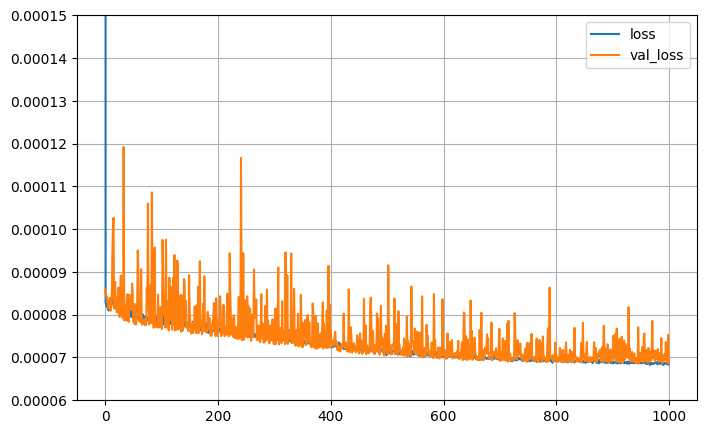

In [ ]:
pd.DataFrame(historyloss).plot(figsize=(8,5))
plt.grid(True)
plt.gca().set_ylim(0.00006,0.00015)
plt.show()

# Ejercicio:

Haga 3 gráficos de la regresión lineal como función de parejas entre 'SPX Return','Time to Maturity in Year','Delta'. Haga que los valores en los ejes sean limitados por los valores reales que existan. El eje de "SPX return" tiene que estar limitado por su máximo y mínimo real, que despues se transformaran con el StandardScaler.

Es decir, 3 gráficos distintos:

x = 'SPX Return', y = 'Time to Maturity in Year', z = modelo_regresion('SPX Return', 'Time to Maturity in Year')

x = 'SPX Return', y = 'Delta', z = modelo_regresion('SPX Return', 'Delta')

x = 'Delta', y = 'Time to Maturity in Year', z = modelo_regresion('Delta', 'Time to Maturity in Year')


Haga lo mismo para la red neuronal

**Importante**: Note el reescalado de las variables y tenga cuidado con eso al graficar

In [ ]:
# Inicio de espacio para ejercicio

# Referencias:

El ejercicio está basado en el capítulo 10 del libro Machine Learning in Business: An Introduction to the World of Data Science, de Jhon C. Hull

https://www-2.rotman.utoronto.ca/~hull/

https://www-2.rotman.utoronto.ca/~hull/MLThirdEditionFiles/mlindex1_3rdEd.html